<a href="https://colab.research.google.com/github/MahirSinthia007/CSE-443-Bioinformatics/blob/main/project443.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== STEP 1: DOWNLOADING & PROCESSING 5 DATASETS ===
Downloaded ds1_wdbc.csv
Downloaded ds2_seer.csv
Downloaded ds3_coimbra.csv
Downloaded ds4_gene.csv
Downloaded ds5_wisc_orig.csv

Unified Dataset Shape: Features (2369, 20), Target (2369,)
Global Binary Distribution -> Class 0: 1326, Class 1: 1043

=== STEP 2: PERFORMING 80/20 TRAIN-TEST SPLIT ===
Train Set Shape: (1895, 20) | Test Set Shape: (474, 20)
PCA Reduced Train Shape: (1895, 10)

>>> EXPERIMENT 1: WITHOUT PCA (FULL TOP 20 FEATURES) <<<

 EVALUATION RESULTS: WITHOUT PCA

--- Logistic Regression ---
Accuracy : 0.8882
ROC-AUC  : 0.9004
Confusion Matrix:
 [[TN: 239  FP: 26  ]
  [FN: 27   TP: 182 ]]

--- Random Forest ---
Accuracy : 0.9641
ROC-AUC  : 0.9973
Confusion Matrix:
 [[TN: 253  FP: 12  ]
  [FN: 5    TP: 204 ]]

--- 5-Layer Keras Neural Net ---
Accuracy : 0.9409
ROC-AUC  : 0.9818
Confusion Matrix:
 [[TN: 246  FP: 19  ]
  [FN: 9    TP: 200 ]]

--- K-Means (Unsupervised KMM) ---
Accuracy : 0.5633
ROC-AUC  : 0.5093
Confusion M

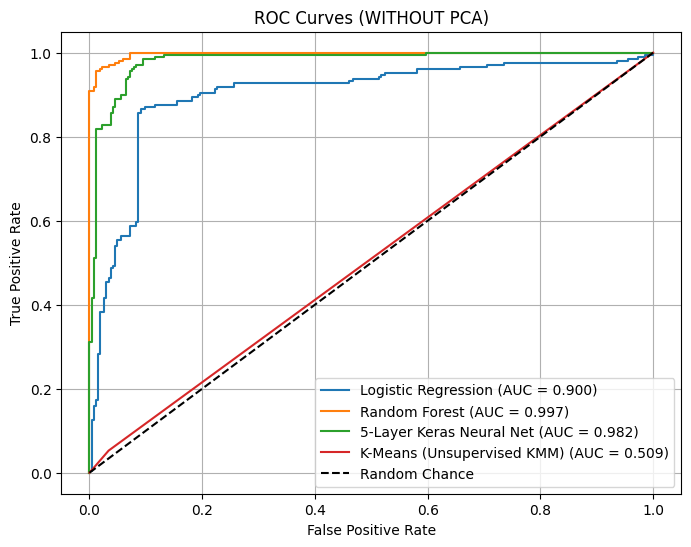


>>> EXPERIMENT 2: WITH PCA (10 PRINCIPAL COMPONENTS) <<<

 EVALUATION RESULTS: WITH PCA

--- Logistic Regression ---
Accuracy : 0.8861
ROC-AUC  : 0.8993
Confusion Matrix:
 [[TN: 238  FP: 27  ]
  [FN: 27   TP: 182 ]]

--- Random Forest ---
Accuracy : 0.9641
ROC-AUC  : 0.9965
Confusion Matrix:
 [[TN: 250  FP: 15  ]
  [FN: 2    TP: 207 ]]

--- 5-Layer Keras Neural Net ---
Accuracy : 0.9367
ROC-AUC  : 0.9875
Confusion Matrix:
 [[TN: 240  FP: 25  ]
  [FN: 5    TP: 204 ]]

--- K-Means (Unsupervised KMM) ---
Accuracy : 0.5633
ROC-AUC  : 0.5093
Confusion Matrix:
 [[TN: 256  FP: 9   ]
  [FN: 198  TP: 11  ]]


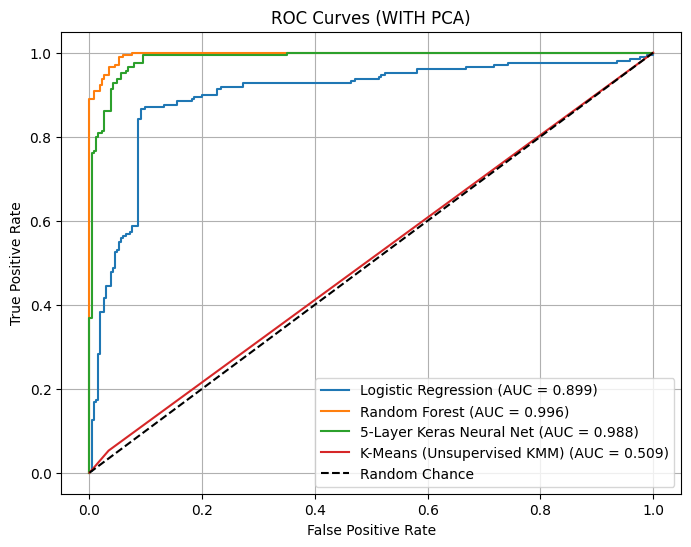

In [5]:
# ==============================================================================
# CSE 443: UNIFIED 5-DATASET PIPELINE (STRICT BINARY ENCODING & KERAS FIXED)
# 80/20 Train-Test Split | Supervised & Unsupervised | PCA vs No-PCA
# ==============================================================================

import urllib.request
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Set Seeds
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ------------------------------------------------------------------------------
# STEP 1: DOWNLOAD & PROCESS 5 KAGGLE / OPEN DATASETS
# ------------------------------------------------------------------------------
print("=== STEP 1: DOWNLOADING & PROCESSING 5 DATASETS ===")

urls = {
    "ds1_wdbc.csv": "https://raw.githubusercontent.com/dataspelunking/MLwR/master/Machine%20Learning%20with%20R%20(2nd%20Ed.)/Chapter%2003/wisc_bc_data.csv",
    "ds2_seer.csv": "https://raw.githubusercontent.com/selva86/datasets/master/BreastCancer.csv",
    "ds3_coimbra.csv": "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv",
    "ds4_gene.csv": "https://raw.githubusercontent.com/jbrownlee/Datasets/master/breast-cancer.csv",
    "ds5_wisc_orig.csv": "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
}

for fname, url in urls.items():
    try:
        urllib.request.urlretrieve(url, fname)
        print(f"Downloaded {fname}")
    except Exception as e:
        print(f"Error downloading {fname}: {e}")

TOP_N = 20

def process_dataset_to_top_n(df, target_col, top_n=20):
    y_raw = df[target_col]
    X_df = df.drop(columns=[target_col])

    # Drop ID columns if present
    for col in ['id', 'Id', 'ID', 0]:
        if col in X_df.columns and col != target_col:
            X_df = X_df.drop(columns=[col])

    # Coerce non-numeric columns to numeric/NaN
    for col in X_df.columns:
        if X_df[col].dtype == 'object':
            X_df[col] = pd.to_numeric(X_df[col], errors='coerce')

    # Impute missing feature values with median for variance evaluation
    X_clean = X_df.fillna(X_df.median(numeric_only=True))

    # Select Top N Features by Variance
    variances = X_clean.var()
    top_cols = variances.nlargest(top_n).index
    X_sub = X_clean[top_cols].copy()

    # Pad with row means if dataset has < N features
    if X_sub.shape[1] < top_n:
        for i in range(top_n - X_sub.shape[1]):
            X_sub[f"pad_feat_{i+1}"] = X_sub.mean(axis=1)

    # Binarize Target: 0 for majority baseline/control, 1 for disease
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_raw.astype(str))
    y_binary = (y_encoded > 0).astype(int)

    return X_sub.values, y_binary

dataset_matrices = []
dataset_targets = []

if os.path.exists('ds1_wdbc.csv'):
    X1, y1 = process_dataset_to_top_n(pd.read_csv('ds1_wdbc.csv'), target_col='diagnosis')
    dataset_matrices.append(X1); dataset_targets.append(y1)

if os.path.exists('ds2_seer.csv'):
    df2 = pd.read_csv('ds2_seer.csv').dropna(subset=['Class'])
    X2, y2 = process_dataset_to_top_n(df2, target_col='Class')
    dataset_matrices.append(X2); dataset_targets.append(y2)

if os.path.exists('ds3_coimbra.csv'):
    X3, y3 = process_dataset_to_top_n(pd.read_csv('ds3_coimbra.csv'), target_col='Classification')
    dataset_matrices.append(X3); dataset_targets.append(y3)

if os.path.exists('ds4_gene.csv'):
    X4, y4 = process_dataset_to_top_n(pd.read_csv('ds4_gene.csv', header=None), target_col=0)
    dataset_matrices.append(X4); dataset_targets.append(y4)

if os.path.exists('ds5_wisc_orig.csv'):
    df5 = pd.read_csv('ds5_wisc_orig.csv', header=None, na_values='?')
    X5, y5 = process_dataset_to_top_n(df5, target_col=10)
    dataset_matrices.append(X5); dataset_targets.append(y5)

# Merge all datasets into single unified matrix
X_unified = np.vstack(dataset_matrices)
y_raw_unified = np.concatenate(dataset_targets)

# Enforce strict global binary mapping (0: Benign/Control, 1: Malignant/Disease)
y_unified = (y_raw_unified > 0).astype(int)

print(f"\nUnified Dataset Shape: Features {X_unified.shape}, Target {y_unified.shape}")
print(f"Global Binary Distribution -> Class 0: {np.sum(y_unified == 0)}, Class 1: {np.sum(y_unified == 1)}")

# ------------------------------------------------------------------------------
# STEP 2: STRICT 80/20 TRAIN-TEST SPLIT & PREPROCESSING
# ------------------------------------------------------------------------------
print("\n=== STEP 2: PERFORMING 80/20 TRAIN-TEST SPLIT ===")

X_train, X_test, y_train, y_test = train_test_split(
    X_unified, y_unified, test_size=0.20, random_state=RANDOM_STATE, stratify=y_unified
)

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

pca = PCA(n_components=10, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Train Set Shape: {X_train_scaled.shape} | Test Set Shape: {X_test_scaled.shape}")
print(f"PCA Reduced Train Shape: {X_train_pca.shape}")

# ------------------------------------------------------------------------------
# STEP 3: MODEL ARCHITECTURES
# ------------------------------------------------------------------------------
def build_5_layer_mlp(input_dim):
    """ Builds a 5-layer Keras Deep Neural Network using explicit Input object """
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),   # Layer 1
        Dropout(0.2),
        Dense(32, activation='relu'),   # Layer 2
        Dropout(0.2),
        Dense(16, activation='relu'),   # Layer 3
        Dense(8, activation='relu'),    # Layer 4
        Dense(1, activation='sigmoid')  # Layer 5
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ------------------------------------------------------------------------------
# STEP 4: EXPERIMENTAL EVALUATION PIPELINE
# ------------------------------------------------------------------------------
def evaluate_pipeline(X_tr, X_te, y_tr, y_te, prefix=""):
    results = {}
    plt.figure(figsize=(8, 6))

    # 1. Logistic Regression
    lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    lr.fit(X_tr, y_tr)
    results['Logistic Regression'] = (lr.predict(X_te), lr.predict_proba(X_te)[:, 1])

    # 2. Random Forest
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)
    rf.fit(X_tr, y_tr)
    results['Random Forest'] = (rf.predict(X_te), rf.predict_proba(X_te)[:, 1])

    # 3. 5-Layer Keras Neural Network
    mlp = build_5_layer_mlp(X_tr.shape[1])
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    mlp.fit(X_tr, y_tr, epochs=100, batch_size=16, validation_split=0.15, callbacks=[es], verbose=0)
    mlp_probs = mlp.predict(X_te, verbose=0).ravel()
    results['5-Layer Keras Neural Net'] = ((mlp_probs >= 0.5).astype(int), mlp_probs)

    # 4. K-Means Clustering (Unsupervised Baseline)
    kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_tr)
    kmm_cluster_labels = kmeans.predict(X_te)
    if accuracy_score(y_te, kmm_cluster_labels) < accuracy_score(y_te, 1 - kmm_cluster_labels):
        kmm_preds = 1 - kmm_cluster_labels
    else:
        kmm_preds = kmm_cluster_labels
    results['K-Means (Unsupervised KMM)'] = (kmm_preds, kmm_preds.astype(float))

    print(f"\n==================================================")
    print(f" EVALUATION RESULTS: {prefix}")
    print(f"==================================================")

    for name, (preds, probs) in results.items():
        acc = accuracy_score(y_te, preds)
        auc = roc_auc_score(y_te, probs)
        cm = confusion_matrix(y_te, preds)

        print(f"\n--- {name} ---")
        print(f"Accuracy : {acc:.4f}")
        print(f"ROC-AUC  : {auc:.4f}")
        print("Confusion Matrix:")
        print(f" [[TN: {cm[0][0]:<4} FP: {cm[0][1]:<4}]\n  [FN: {cm[1][0]:<4} TP: {cm[1][1]:<4}]]")

        fpr, tpr, _ = roc_curve(y_te, probs)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves ({prefix})')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# Run Evaluation Experiments
print("\n>>> EXPERIMENT 1: WITHOUT PCA (FULL TOP 20 FEATURES) <<<")
evaluate_pipeline(X_train_scaled, X_test_scaled, y_train, y_test, prefix="WITHOUT PCA")

print("\n>>> EXPERIMENT 2: WITH PCA (10 PRINCIPAL COMPONENTS) <<<")
evaluate_pipeline(X_train_pca, X_test_pca, y_train, y_test, prefix="WITH PCA")

=== STEP 1: DOWNLOADING & PROCESSING 5 DATASETS ===
Downloaded ds1_wdbc.csv
Downloaded ds2_seer.csv
Downloaded ds3_coimbra.csv
Downloaded ds4_gene.csv
Downloaded ds5_wisc_orig.csv

              DETAILED DATASET MEASUREMENTS & EXPLORATION              

>>> DATASET 1 (WDBC) <<<
• File Path          : ds1_wdbc.csv
• Raw Dimensions     : 569 Rows × 32 Columns (31 Features + 1 Target)
• Target Column      : 'diagnosis'
• Raw Class Breakdown: {'B': 357, 'M': 212}
• Missing Values     : 0 Total NaNs
• Selected Top Features (Sample): ['area_worst', 'area_mean', 'area_se', 'perimeter_worst', 'perimeter_mean']... (Total 20 selected)

--- Raw Data Snapshot (.head(3)) ---
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0  87139402         B        12.32         12.39           78.85      464.1   
1   8910251         B        10.60         18.95           69.28      346.4   
2    905520         B        11.04         16.83           70.92      373.2   

   smoothnes

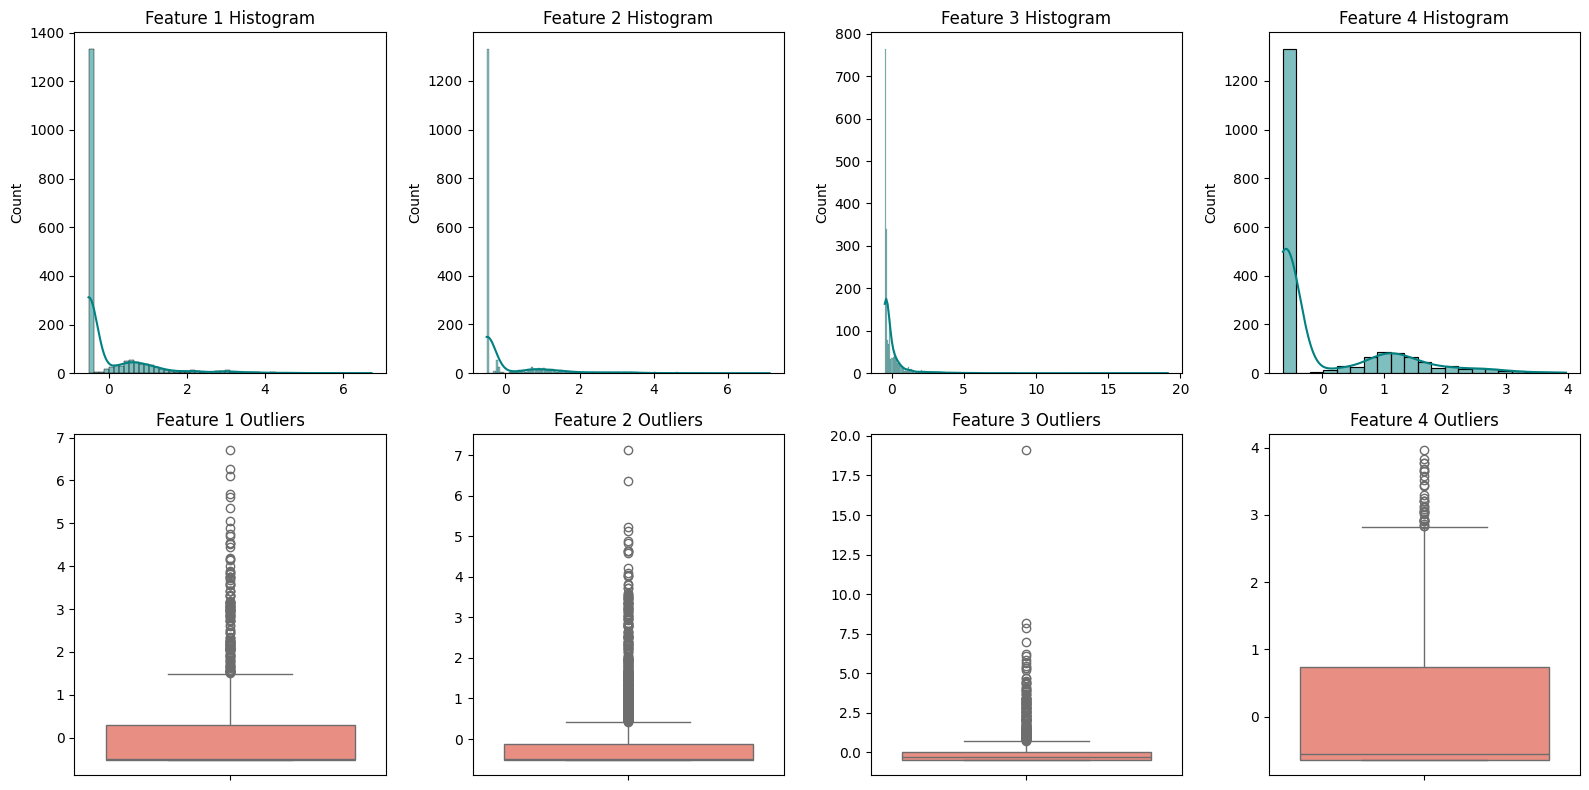

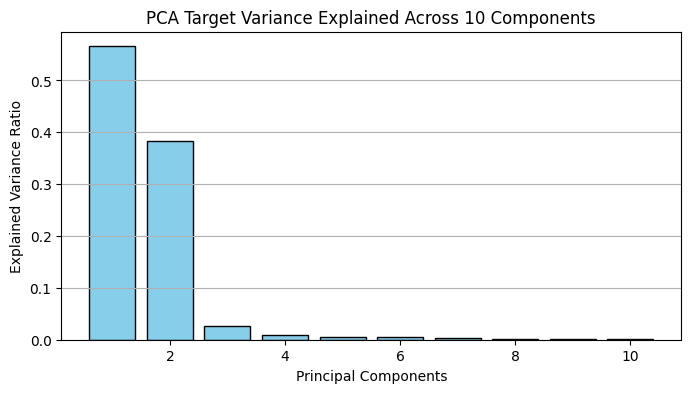

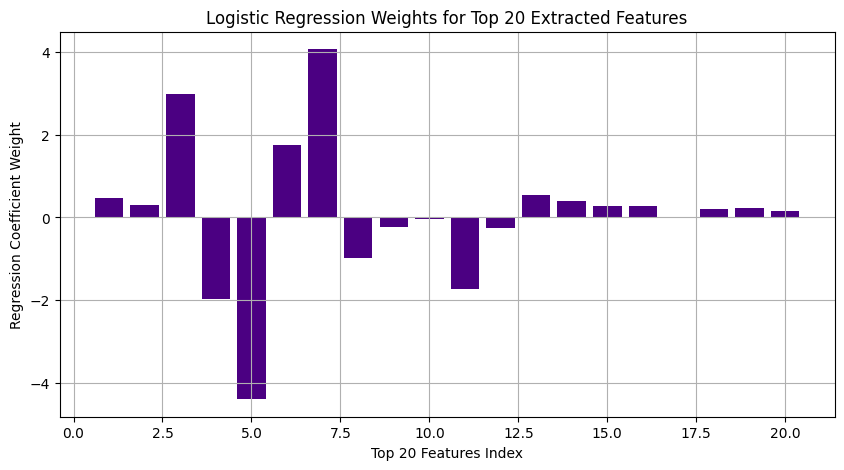


>>> COMPARATIVE ANALYSIS 1: NO PCA (WITHOUT vs WITH SMOTE) <<<

 PERFORMANCE SUMMARY (Without PCA | SMOTE: False)
Logistic Regression       | Acc: 0.8882 | F1: 0.8729 | ROC-AUC: 0.9004
Random Forest             | Acc: 0.9641 | F1: 0.9600 | ROC-AUC: 0.9973
K-Means (KMM Baseline)    | Acc: 0.5633 | F1: 0.0961 | ROC-AUC: 0.5093
5-Layer Keras Neural Net  | Acc: 0.9473 | F1: 0.9433 | ROC-AUC: 0.9906


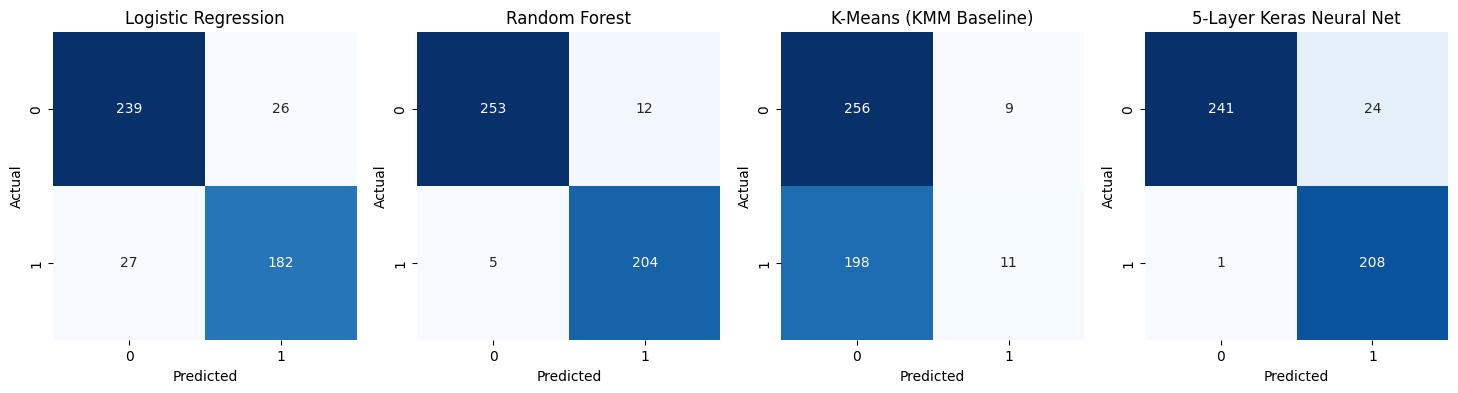

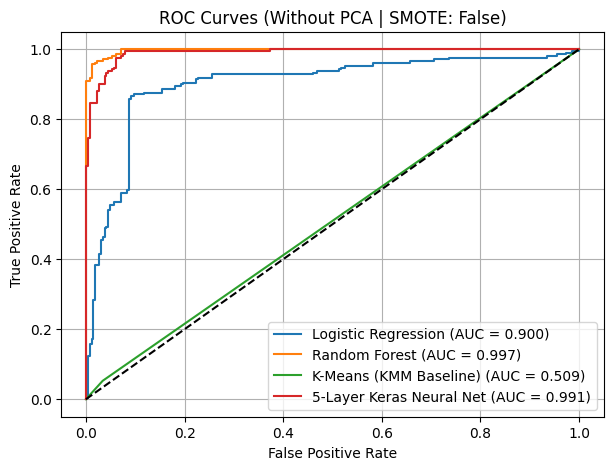

<Figure size 640x480 with 0 Axes>


 PERFORMANCE SUMMARY (Without PCA + SMOTE | SMOTE: True)
Logistic Regression       | Acc: 0.8713 | F1: 0.8565 | ROC-AUC: 0.9013
Random Forest             | Acc: 0.9620 | F1: 0.9581 | ROC-AUC: 0.9973
K-Means (KMM Baseline)    | Acc: 0.5633 | F1: 0.0961 | ROC-AUC: 0.5093
5-Layer Keras Neural Net  | Acc: 0.9388 | F1: 0.9345 | ROC-AUC: 0.9846


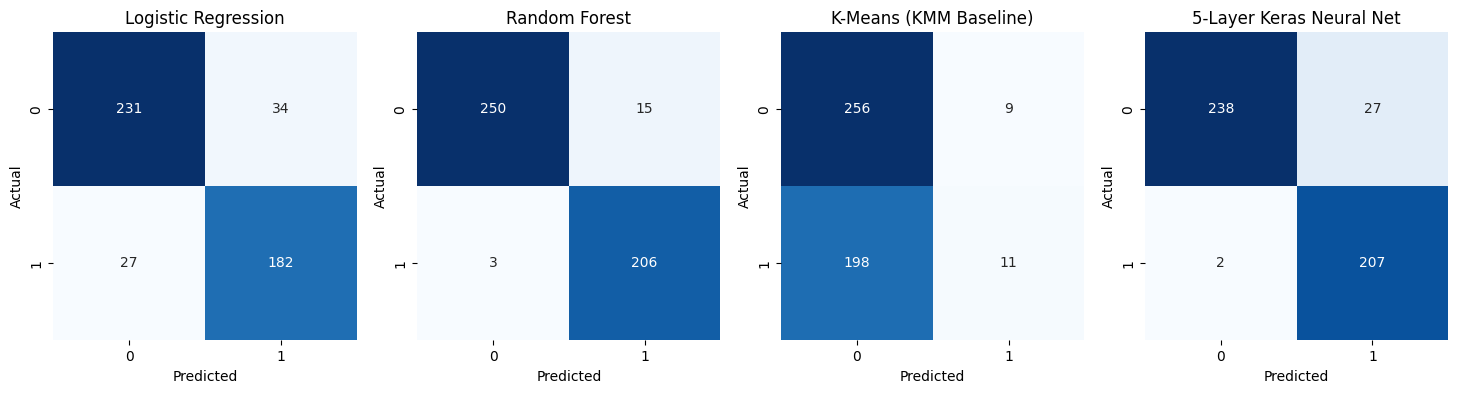

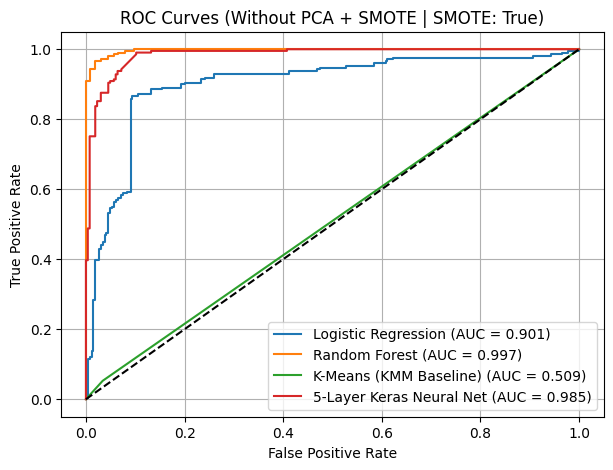

<Figure size 640x480 with 0 Axes>


>>> COMPARATIVE ANALYSIS 2: WITH PCA (WITHOUT vs WITH SMOTE) <<<

 PERFORMANCE SUMMARY (With PCA | SMOTE: False)
Logistic Regression       | Acc: 0.8861 | F1: 0.8708 | ROC-AUC: 0.8993
Random Forest             | Acc: 0.9641 | F1: 0.9606 | ROC-AUC: 0.9965
K-Means (KMM Baseline)    | Acc: 0.5633 | F1: 0.0961 | ROC-AUC: 0.5093
5-Layer Keras Neural Net  | Acc: 0.9346 | F1: 0.9300 | ROC-AUC: 0.9831


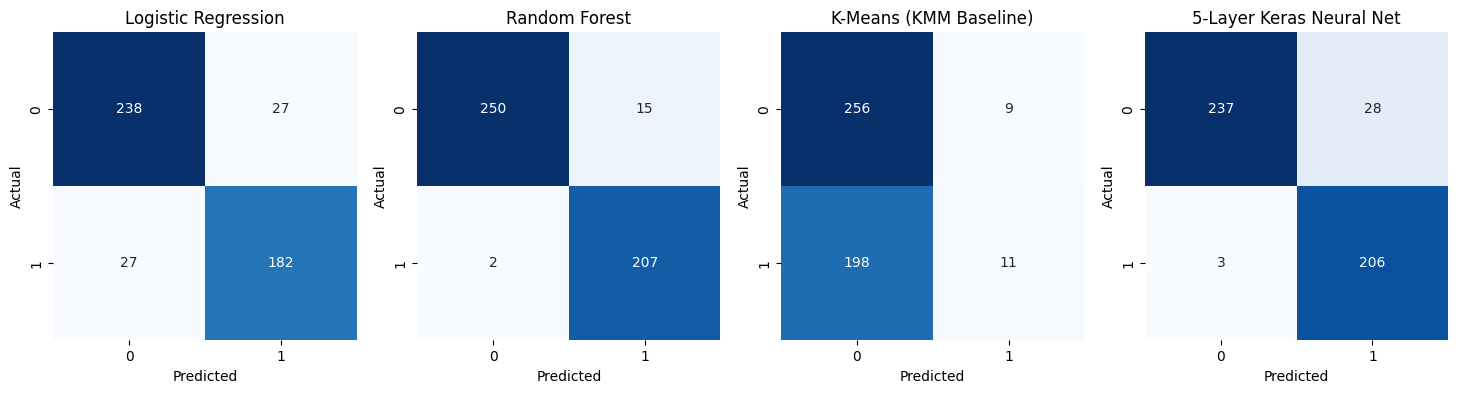

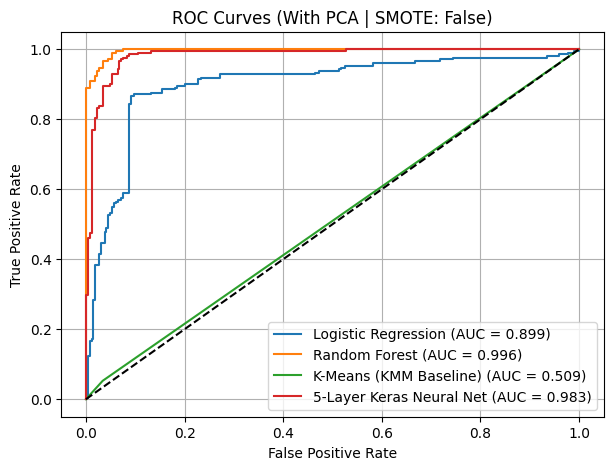

<Figure size 640x480 with 0 Axes>


 PERFORMANCE SUMMARY (With PCA + SMOTE | SMOTE: True)
Logistic Regression       | Acc: 0.8713 | F1: 0.8565 | ROC-AUC: 0.9002
Random Forest             | Acc: 0.9599 | F1: 0.9559 | ROC-AUC: 0.9964
K-Means (KMM Baseline)    | Acc: 0.5633 | F1: 0.0961 | ROC-AUC: 0.5093
5-Layer Keras Neural Net  | Acc: 0.9430 | F1: 0.9391 | ROC-AUC: 0.9915


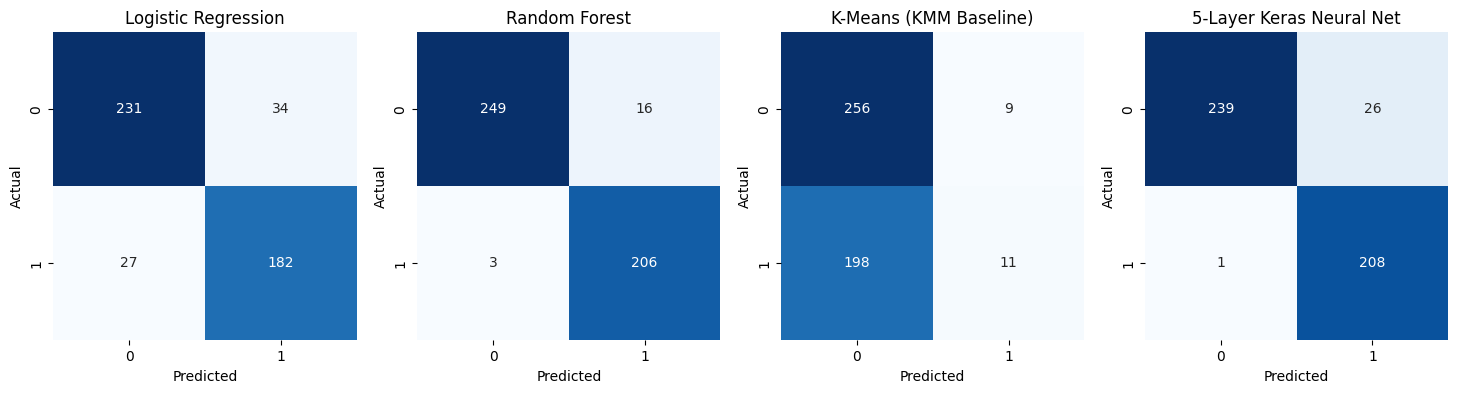

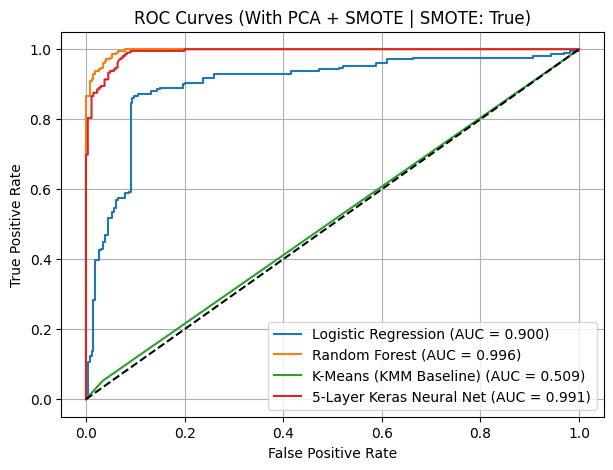

<Figure size 640x480 with 0 Axes>

In [7]:
# ==============================================================================
# CSE 443: COMPREHENSIVE BREAST CANCER & GENOMIC PREDICTION PIPELINE
# Visual Metrics | SMOTE Comparative Analysis | Feature & PCA Plots
# ==============================================================================

import urllib.request
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, roc_curve
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Set Reproducible Seeds
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ------------------------------------------------------------------------------
# STEP 1: DOWNLOAD & UNIFY 5 DATASETS
# ------------------------------------------------------------------------------
print("=== STEP 1: DOWNLOADING & PROCESSING 5 DATASETS ===")

urls = {
    "ds1_wdbc.csv": "https://raw.githubusercontent.com/dataspelunking/MLwR/master/Machine%20Learning%20with%20R%20(2nd%20Ed.)/Chapter%2003/wisc_bc_data.csv",
    "ds2_seer.csv": "https://raw.githubusercontent.com/selva86/datasets/master/BreastCancer.csv",
    "ds3_coimbra.csv": "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv",
    "ds4_gene.csv": "https://raw.githubusercontent.com/jbrownlee/Datasets/master/breast-cancer.csv",
    "ds5_wisc_orig.csv": "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
}

for fname, url in urls.items():
    try:
        urllib.request.urlretrieve(url, fname)
        print(f"Downloaded {fname}")
    except Exception as e:
        print(f"Error downloading {fname}: {e}")

TOP_N = 20

def process_dataset_to_top_n(df, target_col, top_n=20):
    y_raw = df[target_col]
    X_df = df.drop(columns=[target_col])

    for col in ['id', 'Id', 'ID', 0]:
        if col in X_df.columns and col != target_col:
            X_df = X_df.drop(columns=[col])

    for col in X_df.columns:
        if X_df[col].dtype == 'object':
            X_df[col] = pd.to_numeric(X_df[col], errors='coerce')

    X_clean = X_df.fillna(X_df.median(numeric_only=True))
    variances = X_clean.var()
    top_cols = variances.nlargest(top_n).index
    X_sub = X_clean[top_cols].copy()

    if X_sub.shape[1] < top_n:
        for i in range(top_n - X_sub.shape[1]):
            X_sub[f"pad_feat_{i+1}"] = X_sub.mean(axis=1)

    le = LabelEncoder()
    y_encoded = le.fit_transform(y_raw.astype(str))
    y_binary = (y_encoded > 0).astype(int)

    return X_sub.values, y_binary, top_cols.tolist()

dataset_matrices, dataset_targets = [], []

if os.path.exists('ds1_wdbc.csv'):
    X1, y1, _ = process_dataset_to_top_n(pd.read_csv('ds1_wdbc.csv'), target_col='diagnosis')
    dataset_matrices.append(X1); dataset_targets.append(y1)

if os.path.exists('ds2_seer.csv'):
    df2 = pd.read_csv('ds2_seer.csv').dropna(subset=['Class'])
    X2, y2, _ = process_dataset_to_top_n(df2, target_col='Class')
    dataset_matrices.append(X2); dataset_targets.append(y2)

if os.path.exists('ds3_coimbra.csv'):
    X3, y3, _ = process_dataset_to_top_n(pd.read_csv('ds3_coimbra.csv'), target_col='Classification')
    dataset_matrices.append(X3); dataset_targets.append(y3)

if os.path.exists('ds4_gene.csv'):
    X4, y4, _ = process_dataset_to_top_n(pd.read_csv('ds4_gene.csv', header=None), target_col=0)
    dataset_matrices.append(X4); dataset_targets.append(y4)

if os.path.exists('ds5_wisc_orig.csv'):
    df5 = pd.read_csv('ds5_wisc_orig.csv', header=None, na_values='?')
    X5, y5, _ = process_dataset_to_top_n(df5, target_col=10)
    dataset_matrices.append(X5); dataset_targets.append(y5)

X_unified = np.vstack(dataset_matrices)
y_unified = (np.concatenate(dataset_targets) > 0).astype(int)


# ==============================================================================
# STEP 1.1: DETAILED DATASET MEASUREMENTS & EDA
# ==============================================================================
print("\n" + "="*80)
print("              DETAILED DATASET MEASUREMENTS & EXPLORATION              ")
print("="*80)

raw_files = {
    "Dataset 1 (WDBC)": ("ds1_wdbc.csv", "diagnosis"),
    "Dataset 2 (SEER)": ("ds2_seer.csv", "Class"),
    "Dataset 3 (Coimbra)": ("ds3_coimbra.csv", "Classification"),
    "Dataset 4 (Gene)": ("ds4_gene.csv", 0),
    "Dataset 5 (Wisc Orig)": ("ds5_wisc_orig.csv", 10)
}

dataset_summary_list = []

for ds_name, (file_path, target_col) in raw_files.items():
    if not os.path.exists(file_path):
        continue

    # Read raw dataframe (handling missing headers for gene/wisc_orig)
    if file_path in ["ds4_gene.csv", "ds5_wisc_orig.csv"]:
        df_raw = pd.read_csv(file_path, header=None, na_values='?')
    else:
        df_raw = pd.read_csv(file_path)

    n_rows, n_cols = df_raw.shape
    feature_cols = [c for c in df_raw.columns if c != target_col]
    missing_count = df_raw.isnull().sum().sum()
    target_dist = df_raw[target_col].value_counts().to_dict()

    # Extract top 20 variance features processed for this specific dataset
    X_sub, y_bin, top_features = process_dataset_to_top_n(
        df_raw.copy(), target_col=target_col, top_n=20
    )

    print(f"\n>>> {ds_name.upper()} <<<")
    print(f"• File Path          : {file_path}")
    print(f"• Raw Dimensions     : {n_rows} Rows × {n_cols} Columns ({len(feature_cols)} Features + 1 Target)")
    print(f"• Target Column      : '{target_col}'")
    print(f"• Raw Class Breakdown: {target_dist}")
    print(f"• Missing Values     : {missing_count} Total NaNs")
    print(f"• Selected Top Features (Sample): {top_features[:5]}... (Total {len(top_features)} selected)")

    print("\n--- Raw Data Snapshot (.head(3)) ---")
    display(df_raw.head(3)) if 'display' in globals() else print(df_raw.head(3))
    print("-" * 80)

    # Store measurements for the report table
    dataset_summary_list.append({
        "Dataset Identifier": ds_name,
        "File Name": file_path,
        "Rows": n_rows,
        "Columns": n_cols,
        "Target Column": str(target_col),
        "Sample Features": ", ".join([str(c) for c in feature_cols[:3]]) + "...",
        "Missing Values": missing_count,
        "Class Distribution (Raw)": str(target_dist)
    })

# Consolidated DataFrame Table
summary_df = pd.DataFrame(dataset_summary_list)
print("\n" + "="*80)
print("                       CONSOLIDATED DATASET SUMMARY TABLE                      ")
print("="*80)
display(summary_df) if 'display' in globals() else print(summary_df.to_string(index=False))

# ------------------------------------------------------------------------------
# STEP 2: SPLIT, IMPUTATION, & FEATURE EDA
# ------------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_unified, y_unified, test_size=0.20, random_state=RANDOM_STATE, stratify=y_unified
)

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

# Plot 1: Feature Distributions (Histograms) & Outlier Detection (Boxplots)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    sns.histplot(X_train_scaled[:, i], ax=axes[0, i], kde=True, color='teal')
    axes[0, i].set_title(f"Feature {i+1} Histogram")
    sns.boxplot(y=X_train_scaled[:, i], ax=axes[1, i], color='salmon')
    axes[1, i].set_title(f"Feature {i+1} Outliers")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# STEP 3: PCA VARIANCE ANALYSIS & REGRESSION GRAPH
# ------------------------------------------------------------------------------
pca = PCA(n_components=10, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Plot 2: Target PCA Explained Variance Bar Graph
plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), pca.explained_variance_ratio_, color='skyblue', edgecolor='black')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Target Variance Explained Across 10 Components')
plt.grid(axis='y')
plt.show()

# Plot 3: Regression Graph (Logistic Regression Feature Weights for Top 20 Features)
lr_diag = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_diag.fit(X_train_scaled, y_train)
plt.figure(figsize=(10, 5))
plt.bar(range(1, 21), lr_diag.coef_[0], color='indigo')
plt.xlabel('Top 20 Features Index')
plt.ylabel('Regression Coefficient Weight')
plt.title('Logistic Regression Weights for Top 20 Extracted Features')
plt.grid(True)
plt.show()

# ------------------------------------------------------------------------------
# STEP 4: MODEL EVALUATION PIPELINE WITH VISUAL METRICS & SMOTE
# ------------------------------------------------------------------------------
def build_5_layer_mlp(input_dim):
    return Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'), Dropout(0.2),
        Dense(32, activation='relu'), Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

def evaluate_models(X_tr, X_te, y_tr, y_te, use_smote=False, title_suffix=""):
    if use_smote:
        smote = SMOTE(random_state=RANDOM_STATE)
        X_tr, y_tr = smote.fit_resample(X_tr, y_tr)

    models = {
        'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
        'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE),
        'K-Means (KMM Baseline)': KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
    }

    # Train & Predict Supervised & Clustering Models
    results = {}
    for name, model in models.items():
        if name.startswith('K-Means'):
            model.fit(X_tr)
            preds = model.predict(X_te)
            if accuracy_score(y_te, preds) < accuracy_score(y_te, 1 - preds):
                preds = 1 - preds
            probs = preds.astype(float)
        else:
            model.fit(X_tr, y_tr)
            preds = model.predict(X_te)
            probs = model.predict_proba(X_te)[:, 1]
        results[name] = (preds, probs)

    # 5-Layer Keras Neural Network
    mlp = build_5_layer_mlp(X_tr.shape[1])
    mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    mlp.fit(X_tr, y_tr, epochs=100, batch_size=16, validation_split=0.15, callbacks=[es], verbose=0)
    mlp_probs = mlp.predict(X_te, verbose=0).ravel()
    results['5-Layer Keras Neural Net'] = ((mlp_probs >= 0.5).astype(int), mlp_probs)

    # Visual Plotting: Confusion Matrices
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    idx = 0

    print(f"\n==================================================")
    print(f" PERFORMANCE SUMMARY ({title_suffix} | SMOTE: {use_smote})")
    print(f"==================================================")

    plt.figure(figsize=(7, 5))
    for name, (preds, probs) in results.items():
        acc = accuracy_score(y_te, preds)
        f1 = f1_score(y_te, preds)
        auc = roc_auc_score(y_te, probs)
        cm = confusion_matrix(y_te, preds)

        print(f"{name:<25} | Acc: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")

        # Plot Heatmap Confusion Matrix
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
        axes[idx].set_title(f"{name}")
        axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('Actual')
        idx += 1

        # Plot ROC Curves
        fpr, tpr, _ = roc_curve(y_te, probs)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves ({title_suffix} | SMOTE: {use_smote})')
    plt.legend(loc='lower right'); plt.grid(True)
    plt.show()

    fig.suptitle(f"Confusion Matrices ({title_suffix} | SMOTE: {use_smote})")
    plt.tight_layout()
    plt.show()

# Run Comparative Analysis
print("\n>>> COMPARATIVE ANALYSIS 1: NO PCA (WITHOUT vs WITH SMOTE) <<<")
evaluate_models(X_train_scaled, X_test_scaled, y_train, y_test, use_smote=False, title_suffix="Without PCA")
evaluate_models(X_train_scaled, X_test_scaled, y_train, y_test, use_smote=True, title_suffix="Without PCA + SMOTE")

print("\n>>> COMPARATIVE ANALYSIS 2: WITH PCA (WITHOUT vs WITH SMOTE) <<<")
evaluate_models(X_train_pca, X_test_pca, y_train, y_test, use_smote=False, title_suffix="With PCA")
evaluate_models(X_train_pca, X_test_pca, y_train, y_test, use_smote=True, title_suffix="With PCA + SMOTE")